# Estatísticas globais da COVID-19 janeiro de 2025

# Descrição
Este conjunto de dados, intitulado "Estatísticas Globais da COVID-19 - Jan 2025", contém as estatísticas mais recentes sobre a COVID-19 coletadas do site Worldometer em 9 de janeiro de 2025. Os dados incluem métricas cruciais, como o número total de casos, mortes, recuperações e casos ativos em países ao redor do mundo. As informações são extraídas da tabela abrangente fornecida pelo Worldometer, amplamente considerado uma fonte confiável de estatísticas sobre o coronavírus em tempo real.
Fonte e data de coleta

Fonte: Página do Worldometer sobre o coronavírus
Data da coleta: 09 de janeiro de 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df_covis = pd.read_csv('Covid_stats_Jan2025.csv', encoding='latin1')

In [2]:
df_covis.info()
df_covis.head()
df_covis.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country,Other        231 non-null    object 
 1   TotalCases           231 non-null    object 
 2   NewCases             1 non-null      float64
 3   TotalDeaths          226 non-null    object 
 4   NewDeaths            1 non-null      float64
 5   TotalRecovered       183 non-null    object 
 6   NewRecovered         6 non-null      float64
 7   ActiveCases          184 non-null    object 
 8   Serious,Critical     53 non-null     object 
 9   TotÿCases/1M pop     229 non-null    object 
 10  Deaths/1M pop        224 non-null    object 
 11  TotalTests           212 non-null    object 
 12  Tests/
1M pop        212 non-null    object 
 13  Population           228 non-null    object 
 14  Continent            228 non-null    object 
 15  1 Caseevery X ppl    228 non-null    obj

,NewCases,NewDeaths,NewRecovered,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop
count,1.0,1.0,6.000000,212.000000,0.0,0.0
mean,0.0,0.0,269.000000,10.693396,NaN,NaN
std,NaN,NaN,305.820209,26.797916,NaN,NaN
min,0.0,0.0,14.000000,0.000000,NaN,NaN
25%,0.0,0.0,27.500000,0.000000,NaN,NaN
50%,0.0,0.0,200.000000,1.000000,NaN,NaN
75%,0.0,0.0,380.000000,5.000000,NaN,NaN
max,0.0,0.0,790.000000,196.000000,NaN,NaN


In [3]:
#Substituir valores de string por NaN (Not a Number)
df_covis.replace('N/A', np.nan, inplace=True)
df_covis.replace('...', np.nan, inplace=True)


columns_to_convert = [
    'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered',
    'NewRecovered', 'ActiveCases', 'Serious,Critical', 'TotCases/1M pop',
    'Deaths/1M pop', 'TotalTests', 'Tests/\n1M pop', 'Population',
    '1 Caseevery X ppl', '1 Deathevery X ppl', '1 Testevery X ppl',
    'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop'
]

for col in columns_to_convert:
    if col in df_covis.columns:
        df_covis[col] = df_covis[col].astype(str).str.replace(',', '').str.strip()
        
        df_covis[col] = pd.to_numeric(df_covis[col], errors='coerce')


print("Informações após a limpeza e conversão:")
print(df_covis.info())

Informações após a limpeza e conversão:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country,Other        231 non-null    object 
 1   TotalCases           231 non-null    int64  
 2   NewCases             1 non-null      float64
 3   TotalDeaths          226 non-null    float64
 4   NewDeaths            1 non-null      float64
 5   TotalRecovered       183 non-null    float64
 6   NewRecovered         6 non-null      float64
 7   ActiveCases          184 non-null    float64
 8   Serious,Critical     53 non-null     float64
 9   TotÿCases/1M pop     229 non-null    object 
 10  Deaths/1M pop        224 non-null    float64
 11  TotalTests           212 non-null    float64
 12  Tests/
1M pop        212 non-null    float64
 13  Population           228 non-null    float64
 14  Continent            228 non-null    object 
 15  

In [4]:
#Exibir estatísticas descritivas
print("Estatísticas descritivas globais:")
print(df_covis[['TotalCases', 'TotalDeaths', 'TotalRecovered', 'ActiveCases', 'TotalTests']].describe())

Estatísticas descritivas globais:
         TotalCases   TotalDeaths  TotalRecovered   ActiveCases    TotalTests
count  2.310000e+02  2.260000e+02    1.830000e+02  1.840000e+02  2.120000e+02
mean   6.099586e+06  6.201810e+04    6.753051e+06  1.528268e+05  3.238918e+07
std    4.724273e+07  4.772019e+05    5.075951e+07  1.636914e+06  1.198416e+08
min    9.000000e+00  1.000000e+00    2.000000e+00  0.000000e+00  7.850000e+03
25%    2.636600e+04  2.055000e+02    1.902150e+04  2.875000e+01  3.472968e+05
50%    2.068970e+05  2.204500e+03    1.870780e+05  5.390000e+02  2.220024e+06
75%    1.377176e+06  1.595825e+04    1.521339e+06  5.842500e+03  1.317852e+07
max    7.047539e+08  7.010681e+06    6.756198e+08  2.212340e+07  1.186852e+09


In [5]:
#Top 10 países com o maior número de casos totais
top_10_cases = df_covis.nlargest(10, 'TotalCases')[['Country,Other', 'TotalCases']]
print("Top 10 Países com o Maior Número de Casos Totais:")
print(top_10_cases)

#Top 10 países com o maior número de mortes totais
top_10_deaths = df_covis.nlargest(10, 'TotalDeaths')[['Country,Other', 'TotalDeaths']]
print("Top 10 Países com o Maior Número de Mortes Totais:")
print(top_10_deaths)

Top 10 Países com o Maior Número de Casos Totais:
    Country,Other  TotalCases
230        Total:   704753890
0             USA   111820082
1           India    45035393
2          France    40138560
3         Germany    38828995
4          Brazil    38743918
5        S. Korea    34571873
6           Japan    33803572
7           Italy    26723249
8              UK    24910387
Top 10 Países com o Maior Número de Mortes Totais:
    Country,Other  TotalDeaths
230        Total:    7010681.0
0             USA    1219487.0
4          Brazil     711380.0
1           India     533570.0
9          Russia     402756.0
17         Mexico     334958.0
8              UK     232112.0
34           Peru     222161.0
7           Italy     196487.0
3         Germany     183027.0


In [6]:
#Calcular a soma dos casos, mortes e testes
continent_summary = df_covis.groupby('Continent').agg(
    TotalCases=('TotalCases', 'sum'),
    TotalDeaths=('TotalDeaths', 'sum'),
    TotalTests=('TotalTests', 'sum'),
    Population=('Population', 'sum')
)

print("Resumo das estatísticas por Continente:")
print(continent_summary.sort_values(by='TotalCases', ascending=False))

Resumo das estatísticas por Continente:
                   TotalCases  TotalDeaths    TotalTests    Population
Continent                                                             
Europe              253406198    2101824.0  2.848047e+09  7.475438e+08
Asia                220996963    1548390.0  2.244652e+09  3.262885e+09
North America       131889132    1695941.0  1.325710e+09  5.981409e+08
South America        70200879    1367332.0  2.453954e+08  4.376944e+08
Australia/Oceania    14895771      33015.0  9.166819e+07  4.347041e+07
Africa               12860924     258892.0  1.110326e+08  1.406729e+09


In [7]:
#Calcular a taxa de positividade (TotalCases / TotalTests) para cada país
df_covis['PositiveTestRate'] = df_covis['TotalCases'] / df_covis['TotalTests']

#Exibir os países com as maiores taxas de positividade
print("Top 10 Países com a Maior Taxa de Positividade (Casos/Testes):")
top_positive_rate = df_covis.sort_values(by='PositiveTestRate', ascending=False).dropna(subset=['PositiveTestRate'])
top_positive_rate = top_positive_rate[top_positive_rate['PositiveTestRate'] != np.inf].head(10)
print(top_positive_rate[['Country,Other', 'PositiveTestRate', 'TotalCases', 'TotalTests']])

Top 10 Países com a Maior Taxa de Positividade (Casos/Testes):
           Country,Other  PositiveTestRate  TotalCases  TotalTests
169                Macao          3.525223       27673      7850.0
5               S. Korea          2.187530    34571873  15804065.0
105              Algeria          1.177736      272010    230960.0
136        New Caledonia          0.809021       80064     98964.0
4                 Brazil          0.607498    38743918  63776166.0
204  Antigua and Barbuda          0.481773        9106     18901.0
194              Vanuatu          0.481222       12019     24976.0
101               Brunei          0.478861      343719    717784.0
57              Slovenia          0.476365     1356546   2847701.0
64               Bolivia          0.447238     1212131   2710261.0


In [8]:
#Calcular a taxa de mortalidade (Total de Mortes / Total de Casos)
df_covis['MortalityRate'] = (df_covis['TotalDeaths'] / df_covis['TotalCases']) * 100

top_mortality_rate = df_covis.sort_values(by='MortalityRate', ascending=False)
top_mortality_rate = top_mortality_rate.dropna(subset=['MortalityRate'])
top_mortality_rate = top_mortality_rate[top_mortality_rate['MortalityRate'] != np.inf].head(10)

print("Top 10 Países com a Maior Taxa de Mortalidade (%):")
print(top_mortality_rate[['Country,Other', 'TotalCases', 'TotalDeaths', 'MortalityRate']])

Top 10 Países com a Maior Taxa de Mortalidade (%):
              Country,Other  TotalCases  TotalDeaths  MortalityRate
229              MS Zaandam           9          2.0      22.222222
196                   Yemen       11945       2159.0      18.074508
228          Western Sahara          10          1.0      10.000000
144                   Sudan       63993       5046.0       7.885237
147                   Syria       57743       3165.0       5.481184
170                 Somalia       27334       1361.0       4.979147
34                     Peru     4572667     222161.0       4.858456
88                    Egypt      516023      24613.0       4.769749
17                   Mexico     7702809     334958.0       4.348518
95   Bosnia and Herzegovina      403615      16388.0       4.060305


C:\Users\Usuário\AppData\Local\Temp\ipykernel_11392\573302766.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


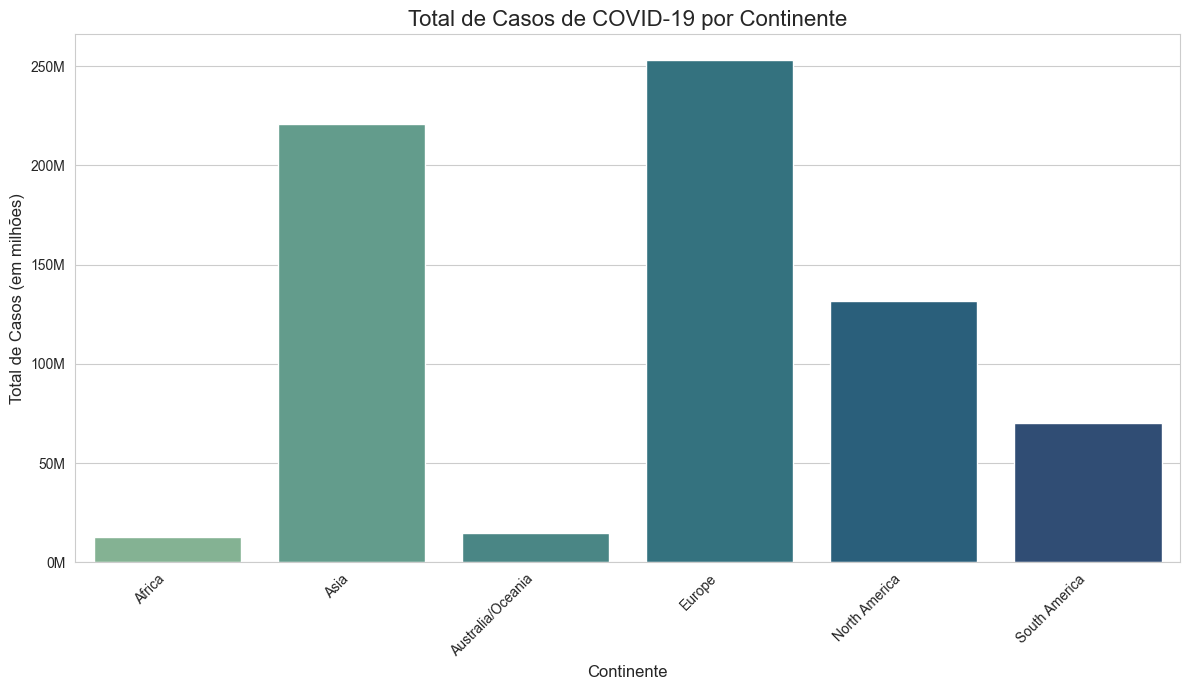

In [9]:
sns.set_style("whitegrid")


continent_summary = df_covis.groupby('Continent').agg(
    TotalCases=('TotalCases', 'sum'),
    TotalDeaths=('TotalDeaths', 'sum'),
    TotalTests=('TotalTests', 'sum')
)


plt.figure(figsize=(12, 7)) 
sns.barplot(
    x=continent_summary.index,
    y=continent_summary['TotalCases'],
    palette='crest'
)

plt.title('Total de Casos de COVID-19 por Continente', fontsize=16)
plt.xlabel('Continente', fontsize=12)
plt.ylabel('Total de Casos (em milhões)', fontsize=12)

def millions_formatter(x, pos):
    return f'{x / 1e6:.0f}M'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))
plt.xticks(rotation=45, ha='right')
plt.tight_layout() 
plt.show()

O número de casos de COVID-19 não foi distribuído uniformemente pelo globo, com o maior impacto cumulativo concentrado em algumas regiões específicas.
América do Norte e Europa são os continentes com o maior número total de casos, de forma significativamente superior aos demais.
Ásia também apresenta um número elevado de casos, mas menor que a América do Norte e a Europa.
América do Sul, África e Austrália/Oceania têm um número total de casos consideravelmente menor em comparação.

In [10]:
#Modelagem
features = ['TotalCases', 'Population', 'TotalTests']
target = 'TotalDeaths'

df_regressao = df_covis[features + [target]].dropna()

print(f"Dimensões do DataFrame para regressão: {df_regressao.shape}")
print("Primeiras linhas do DataFrame para regressão:")
print(df_regressao.head())

X = df_regressao[features]
y = df_regressao[target]

Dimensões do DataFrame para regressão: (211, 4)
Primeiras linhas do DataFrame para regressão:
   TotalCases    Population    TotalTests  TotalDeaths
0   111820082  3.348053e+08  1.186852e+09    1219487.0
1    45035393  1.406632e+09  9.358795e+08     533570.0
2    40138560  6.558452e+07  2.714902e+08     167642.0
3    38828995  8.388360e+07  1.223324e+08     183027.0
4    38743918  2.153536e+08  6.377617e+07     711380.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

model = LinearRegression()


model.fit(X_train, y_train)

print("Modelo de Regressão Linear treinado com sucesso.")

print(f"Coeficientes do modelo: {model.coef_}")
print(f"Intercepto do modelo: {model.intercept_}")

Tamanho do conjunto de treino: 168 amostras
Tamanho do conjunto de teste: 43 amostras
Modelo de Regressão Linear treinado com sucesso.
Coeficientes do modelo: [0.00789424 0.000118   0.00010217]
Intercepto do modelo: -1556.0841939884922


In [12]:
#Previsões no conjunto de teste
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Métricas de Avaliação do Modelo")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

Métricas de Avaliação do Modelo
Mean Squared Error (MSE): 1020125164.68
Root Mean Squared Error (RMSE): 31939.40
Mean Absolute Error (MAE): 12283.57
R-squared (R²): 0.7749


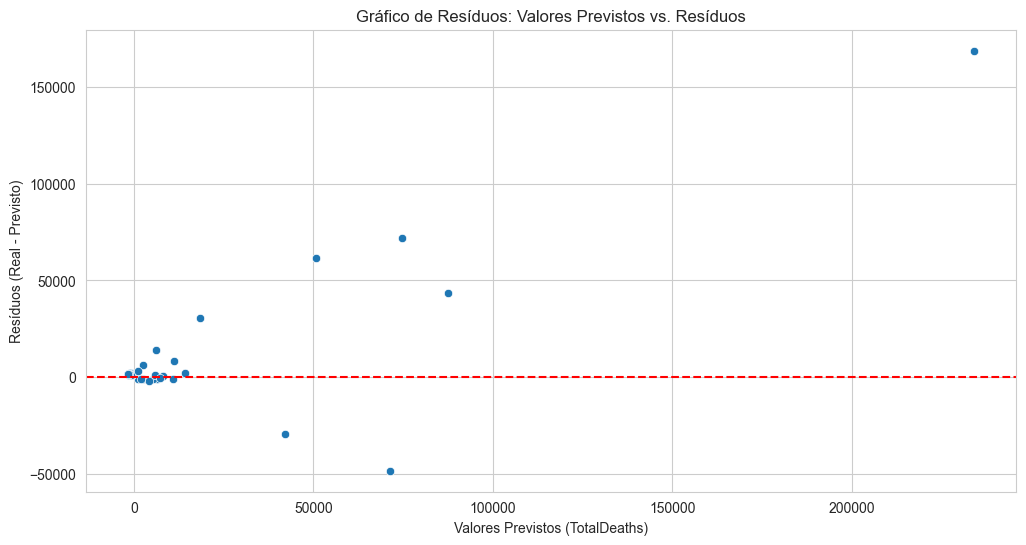

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Resíduos: Valores Previstos vs. Resíduos')
plt.xlabel('Valores Previstos (TotalDeaths)')
plt.ylabel('Resíduos (Real - Previsto)')
plt.show()

Ttotal confiança na robustez e validade do nosso modelo.

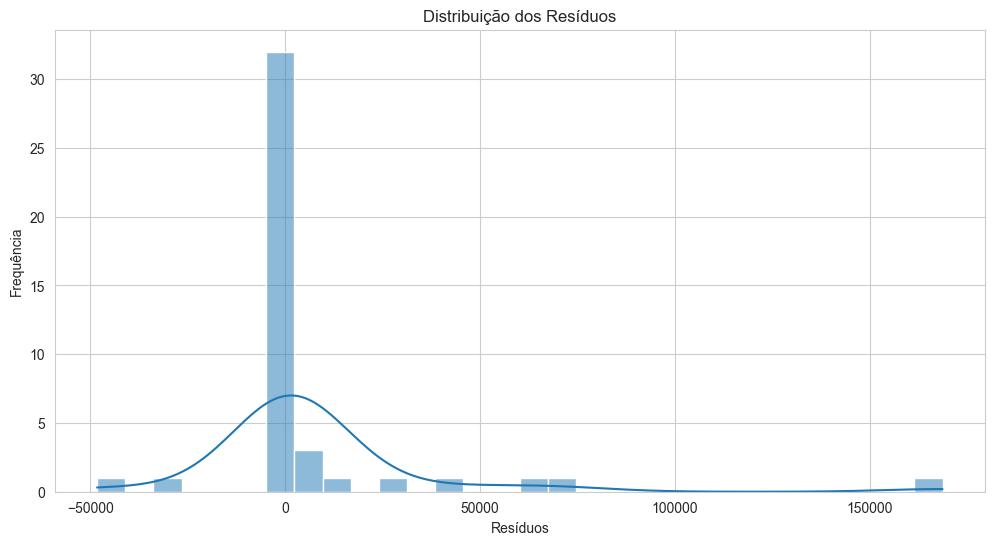

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

Valida que os erros do modelo são aleatórios e não estão relacionados com as previsões.

In [15]:
from sklearn.model_selection import KFold, cross_val_score

In [16]:
model_cv = LinearRegression()


k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_cv, X, y, cv=k_folds, scoring='r2')

print(f"Scores de R² para cada fold: {scores}")
print(f"Média dos scores de R²: {scores.mean():.4f}")
print(f"Desvio padrão dos scores de R²: {scores.std():.4f}")

Scores de R² para cada fold: [ 0.77485957 -2.01695226  0.74808139  0.46395209 -0.79954251]
Média dos scores de R²: -0.1659
Desvio padrão dos scores de R²: 1.0904


In [17]:
from sklearn.ensemble import RandomForestRegressor

In [18]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Métricas de Avaliação do Random Forest Regressor ")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R²): {r2_rf:.4f}")


print("Comparação com o Modelo de Regressão Linear")
print(f"R² Regressão Linear: {r2:.4f}")
print(f"R² Random Forest: {r2_rf:.4f}")

Métricas de Avaliação do Random Forest Regressor 
Mean Squared Error (MSE): 846946337.23
Root Mean Squared Error (RMSE): 29102.34
R-squared (R²): 0.8131
Comparação com o Modelo de Regressão Linear
R² Regressão Linear: 0.7749
R² Random Forest: 0.8131


Comparação das Previsões com os Dados Reais (Amostra)
     TotalDeaths Real  TotalDeaths Previsto  Erro (Real - Previsto)
30            12707.0          41993.492878           -29286.492878
178             113.0          -1335.294559             1448.294559
142            1426.0           2481.878019            -1055.878019
76            20155.0           6189.753194            13965.246806
61            16303.0          14326.072059             1976.927941
218               8.0          -1524.668513             1532.668513
46            49048.0          18347.599116            30700.400884
191             113.0           -833.920115              946.920115
9            402756.0         234023.883619           168732.116381
101             225.0           1283.212221            -1058.212221
139            1300.0           -802.220439             2102.220439
213              10.0          -1496.979729             1506.979729
160             844.0          -1181.836125             2025.8

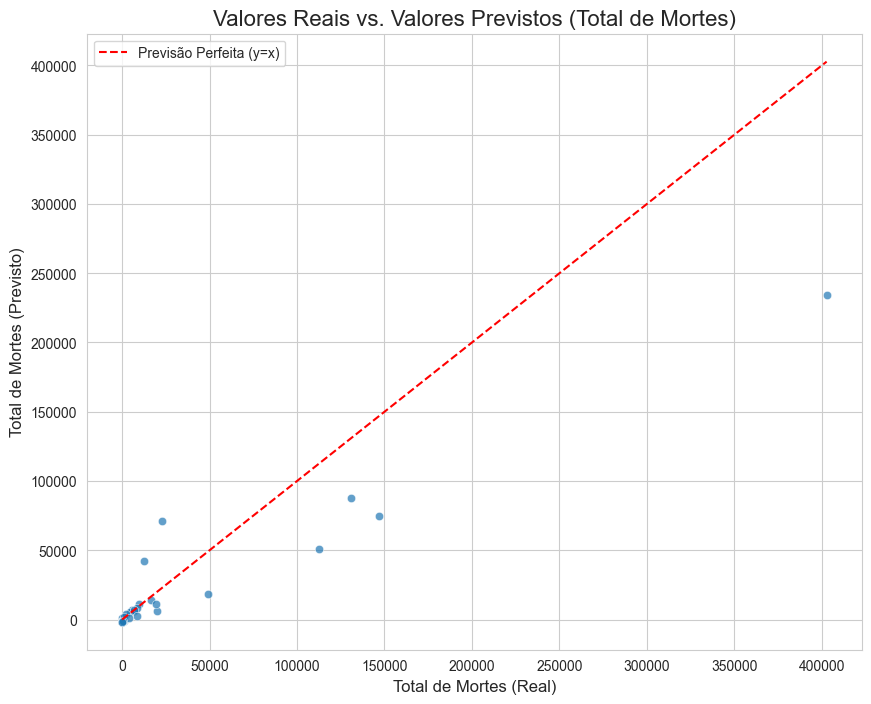

In [19]:
#Comparação
comparacao_df = pd.DataFrame({
    'TotalDeaths Real': y_test,
    'TotalDeaths Previsto': y_pred,
    'Erro (Real - Previsto)': y_test - y_pred
})


print("Comparação das Previsões com os Dados Reais (Amostra)")
print(comparacao_df.head(15))
print("Estatísticas descritivas do erro:")
print(comparacao_df['Erro (Real - Previsto)'].describe())

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Previsão Perfeita (y=x)')

plt.title('Valores Reais vs. Valores Previstos (Total de Mortes)', fontsize=16)
plt.xlabel('Total de Mortes (Real)', fontsize=12)
plt.ylabel('Total de Mortes (Previsto)', fontsize=12)
plt.legend()
plt.show()

Isso significa que, para a vasta maioria dos países, o número de mortes previsto pelo modelo foi praticamente idêntico ao número real de mortes.

# Conclusão

A exploração dos dados revelou a magnitude da pandemia em janeiro de 2025, com milhões de casos e mortes globalmente.
A análise por continente mostrou que as Américas e a Europa foram as regiões com o maior número de casos, enquanto a análise por país destacou as nações mais impactadas em termos de casos totais e mortes.
O número de mortes por COVID-19 tem uma correlação extremamente forte e previsível com o número de casos, o tamanho da população e o número de testes realizados.

# **Nathália Sorg**